In [1]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
import shap
import os
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

In [2]:
df = pd.read_excel("../data/data_cleaned_featured.xlsx")

In [3]:
df.shape

(7032, 28)

In [4]:
df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Total Charges,Churn Label,Total Services,New Customer,Avg Monthly Spend,Services_per_Month,High_Value,Security Bundle,Entertainment Bundle,Long-Term Customer
0,Male,No,No,No,2,Yes,No,Dsl,Yes,Yes,...,108.15,Yes,3,1,54.075000,1.500000,0,1,0,0
1,Female,No,No,Yes,2,Yes,No,Fiber Optic,No,No,...,151.65,Yes,1,1,75.825000,0.500000,1,0,0,0
2,Female,No,No,Yes,8,Yes,Yes,Fiber Optic,No,No,...,820.50,Yes,5,1,102.562500,0.625000,1,1,2,0
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber Optic,No,No,...,3046.05,Yes,6,0,108.787500,0.214286,1,2,2,1
4,Male,No,No,Yes,49,Yes,Yes,Fiber Optic,No,Yes,...,5036.30,Yes,6,0,102.781633,0.122449,1,1,2,1


In [5]:
df.isnull().sum().sum()

np.int64(0)

In [6]:

X = df.drop("Churn Label", axis=1)
y = df["Churn Label"]

In [7]:
print("Features:", X.shape)
print("Target:", y.shape)

Features: (7032, 27)
Target: (7032,)


In [8]:
y = y.map({
    'No': 0,
    'Yes': 1
})

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [10]:
pipeline = joblib.load("../model/churn_pipeline.pkl")

In [11]:
feature_name_mapping = joblib.load("../model/feature_name_mapping.pkl")

In [12]:
preprocessor = pipeline.named_steps["preprocessor"]
model = pipeline.named_steps["classifier"]

In [13]:
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [14]:
feature_names = preprocessor.get_feature_names_out()

In [15]:
readable_feature_names = [
    feature_name_mapping.get(feature, feature)
    for feature in feature_names
]

In [16]:
print(readable_feature_names)
print(len(readable_feature_names))
print(len(feature_names))

['Customer Tenure', 'Monthly Charges', 'Total Charges', 'Total Services', 'New Customer', 'Average Monthly Spend', 'Services per Month', 'High Value Customer', 'Security Bundle', 'Entertainment Bundle', 'Long-Term Customer', 'Female', 'Male', 'Not Senior Citizen', 'Senior Citizen', 'No Partner', 'Has Partner', 'No Dependents', 'Has Dependents', 'No Phone Service', 'Phone Service', 'No Multiple Lines', 'No Phone Service (Multiple Lines)', 'Multiple Lines', 'DSL Internet', 'Fiber Optic Internet', 'No Internet Service', 'No Online Security', 'No Internet Service (Security)', 'Online Security', 'No Online Backup', 'No Internet Service (Backup)', 'Online Backup', 'No Device Protection', 'No Internet Service (Device Protection)', 'Device Protection', 'No Tech Support', 'No Internet Service (Tech Support)', 'Tech Support', 'No Streaming TV', 'No Internet Service (Streaming TV)', 'Streaming TV', 'No Streaming Movies', 'No Internet Service (Streaming Movies)', 'Streaming Movies', 'Month-to-Mont

In [17]:
joblib.dump(readable_feature_names, "../model/readable_feature_names.pkl")

['../model/readable_feature_names.pkl']

In [18]:
y_prob = pipeline.predict_proba(X_test)[:, 1]

threshold = joblib.load("../model/threshold.pkl")
y_pred = (y_prob >= threshold).astype(int)

In [19]:
print(y_train.head())
print(y_test.head())

2902    0
7003    0
4340    0
5178    0
4479    0
Name: Churn Label, dtype: int64
2592    0
2336    0
5025    0
975     1
5204    0
Name: Churn Label, dtype: int64


In [20]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}")

Accuracy : 0.8003
Precision: 0.6177
Recall   : 0.6524
F1 Score : 0.6346
ROC-AUC  : 0.8443


In [21]:
explainer = shap.Explainer(
    model,
    masker=shap.maskers.Independent(
        X_train_processed,
        max_samples=500
    )
)

Background dataset has 5625 samples but max_samples=500. Subsampling to 500 samples for SHAP value computation. To use all samples, set max_samples=5625 when initializing the masker.


In [22]:
shap_values = explainer(X_test_processed)


In [23]:
shap_values.feature_names = readable_feature_names

In [24]:
np.shape(shap_values.values)

(1407, 54)

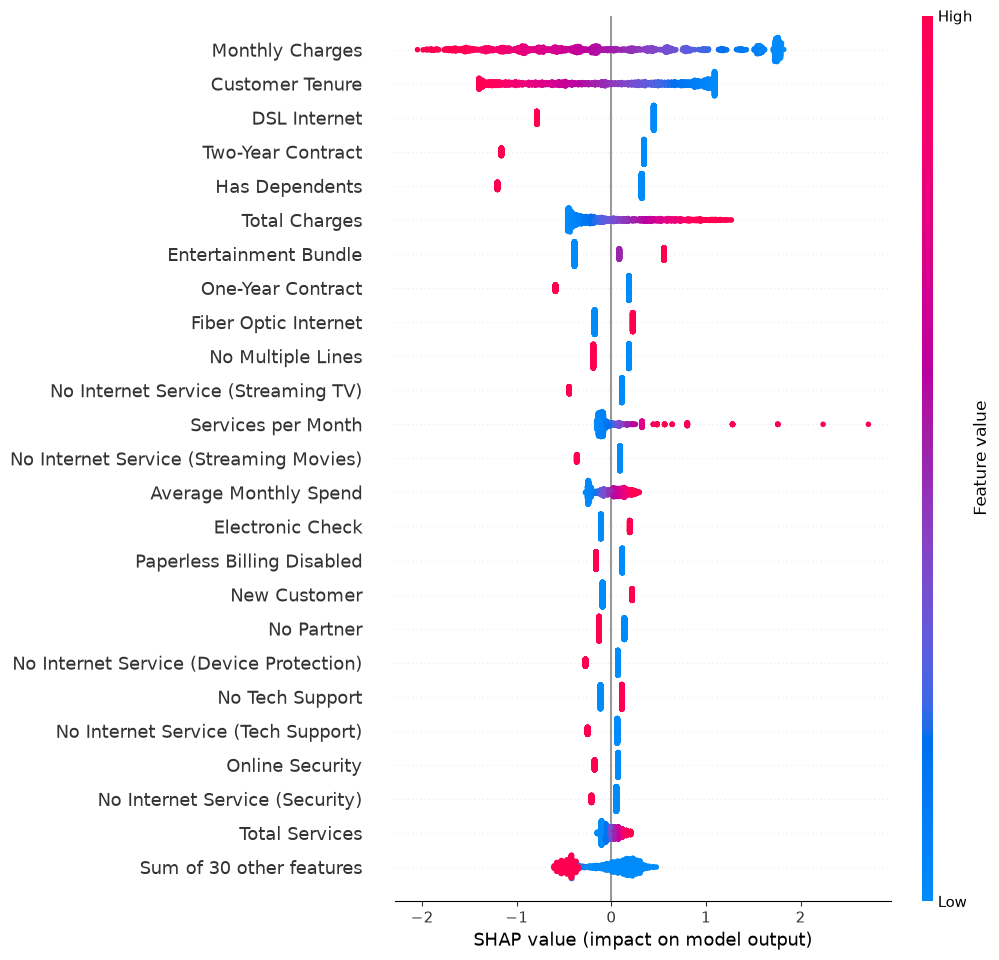

In [25]:
shap.plots.beeswarm(shap_values, max_display=25)

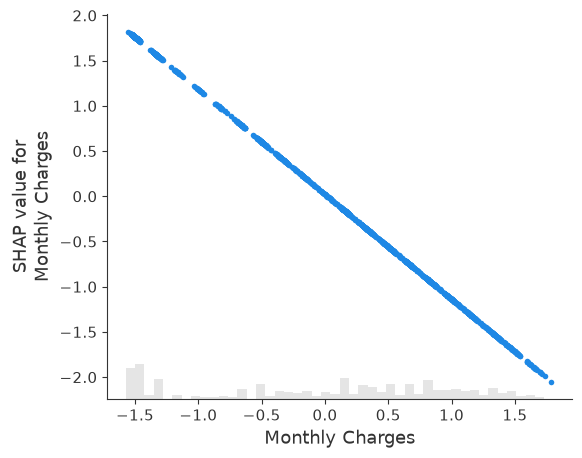

In [26]:
shap.plots.scatter(shap_values[:, "Monthly Charges"])

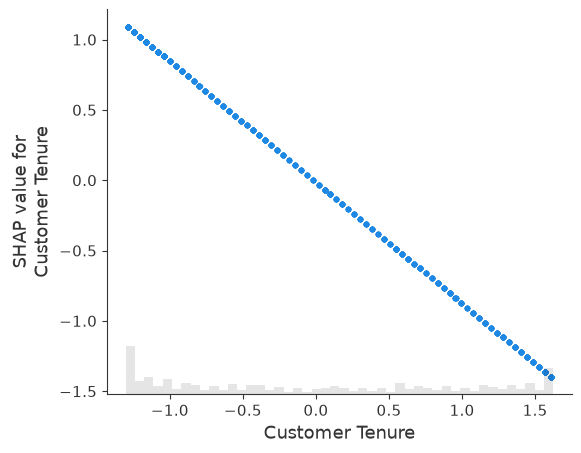

In [27]:
shap.plots.scatter(shap_values[:, "Customer Tenure"])

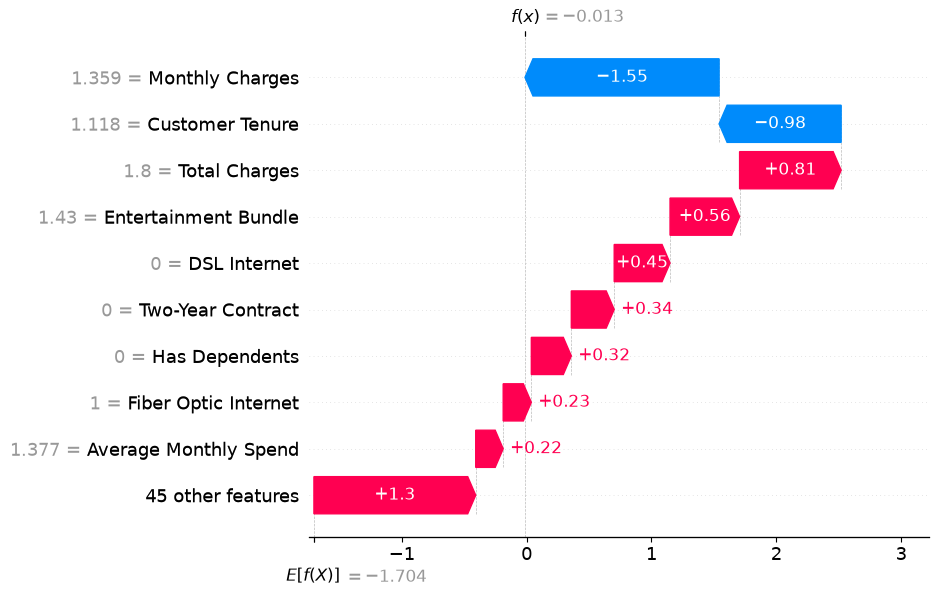

In [28]:
shap.plots.waterfall(shap_values[5])

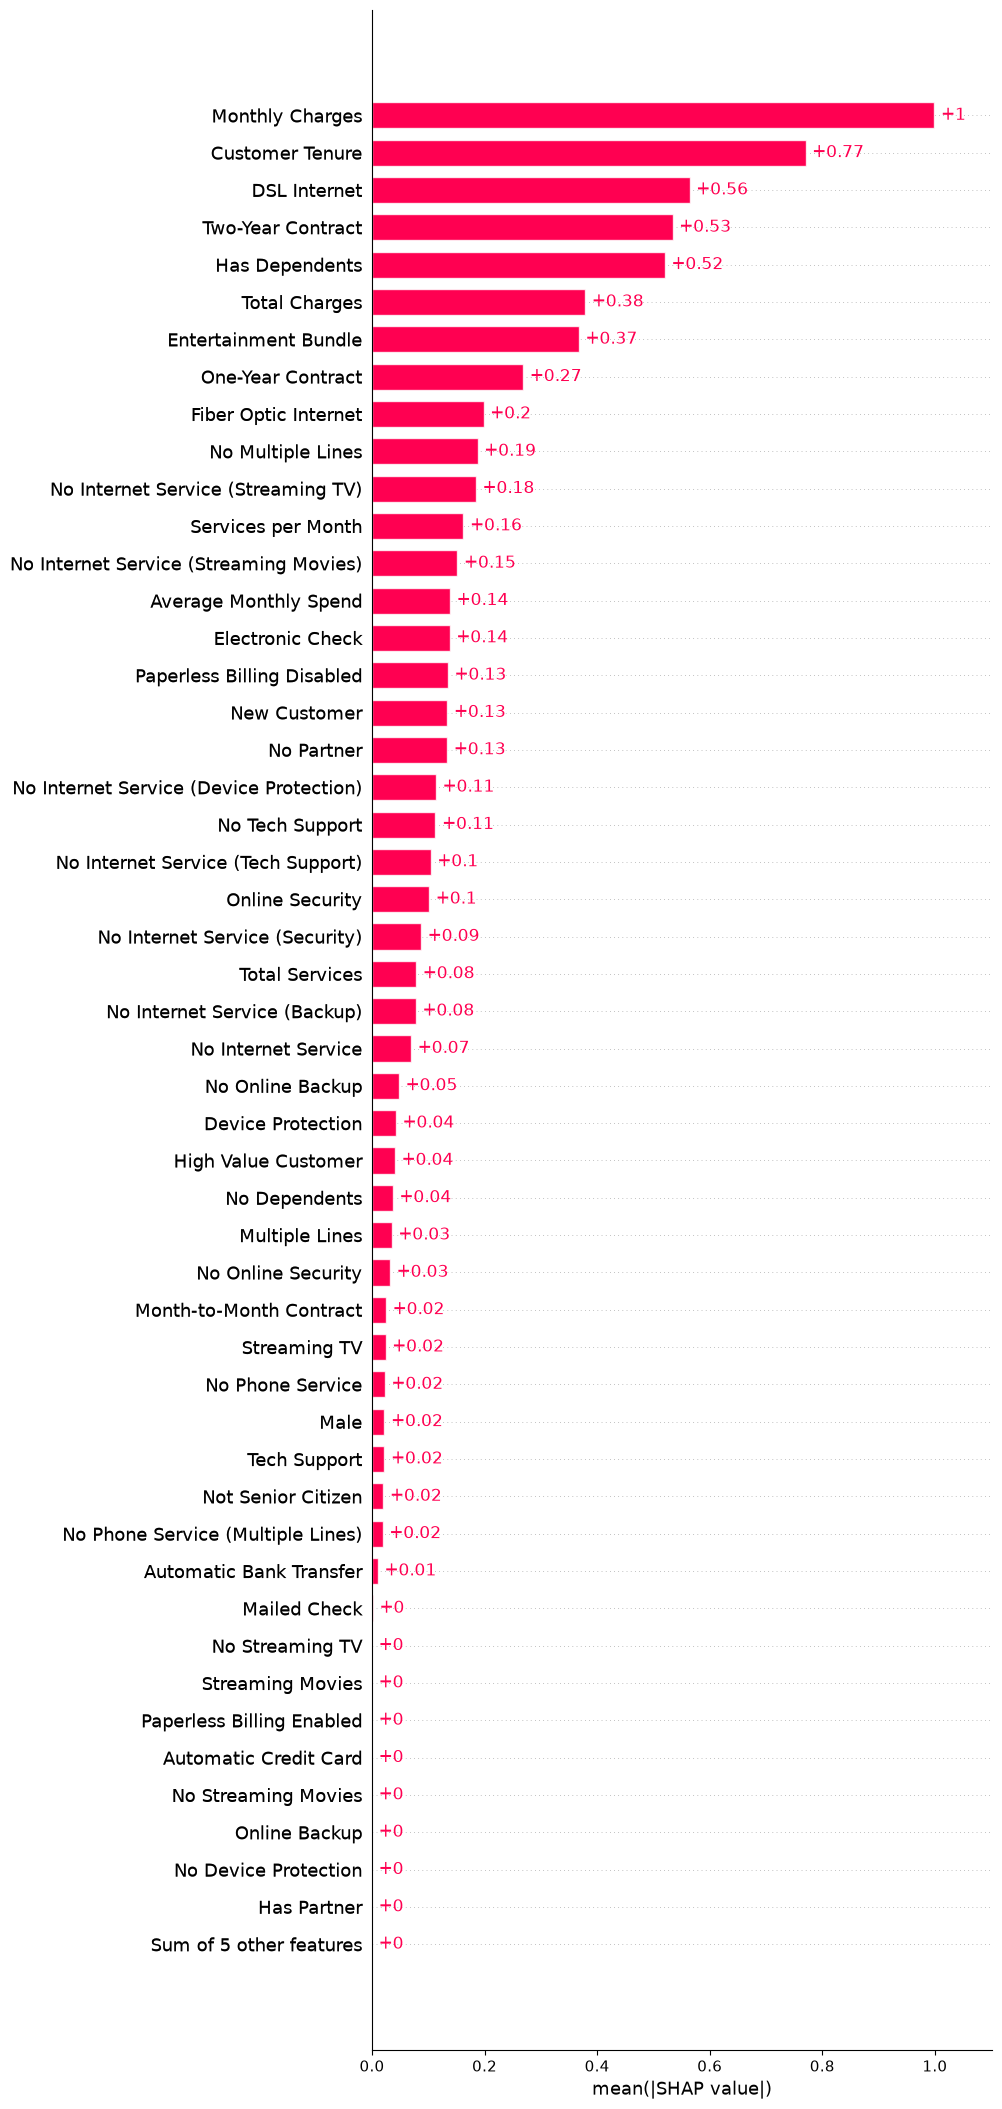

In [29]:
shap.plots.bar(shap_values, max_display=50)

In [41]:
customer_idx = 5

customer = X_test.iloc[customer_idx]
customer

Gender                            Female
Senior Citizen                        No
Partner                               No
Dependents                            No
Tenure Months                         60
Phone Service                        Yes
Multiple Lines                       Yes
Internet Service             Fiber Optic
Online Security                       No
Online Backup                        Yes
Device Protection                    Yes
Tech Support                          No
Streaming TV                         Yes
Streaming Movies                     Yes
Contract                  Month-To-Month
Paperless Billing                    Yes
Payment Method          Electronic Check
Monthly Charges                    105.9
Total Charges                    6396.45
Total Services                         6
New Customer                           0
Avg Monthly Spend               106.6075
Services_per_Month                   0.1
High_Value                             1
Security Bundle 

In [31]:
probability = pipeline.predict_proba(X_test.iloc[[customer_idx]])[0, 1]

threshold = joblib.load("../model/threshold.pkl")

prediction = "Churn" if probability >= threshold else "No Churn"

print(f"Probability: {probability:.2%}")
print(f"Prediction : {prediction}")

Probability: 49.67%
Prediction : Churn


In [32]:
customer_shap = shap_values[customer_idx].values

importance = pd.DataFrame({
    "Feature": readable_feature_names,
    "SHAP Value": customer_shap
})

In [33]:
importance = importance.sort_values(
    by="SHAP Value",
    key=abs,
    ascending=False
)

importance.head(10)

,Feature,SHAP Value
1,Monthly Charges,-1.554629
0,Customer Tenure,-0.977448
2,Total Charges,0.813297
9,Entertainment Bundle,0.557047
24,DSL Internet,0.447301
47,Two-Year Contract,0.343487
18,Has Dependents,0.320215
25,Fiber Optic Internet,0.225400
5,Average Monthly Spend,0.220043
52,Electronic Check,0.193858


In [43]:
customer_idx = 5

customer_original = X_test.iloc[customer_idx]

customer_shap = pd.DataFrame({
    "Feature": readable_feature_names,
    "SHAP": shap_values[customer_idx].values,
    "Feature Value": X_test_processed[customer_idx]
})

customer_shap.sort_values(
    "SHAP",
    key=abs,
    ascending=False
).head(15)

,Feature,SHAP,Feature Value
1,Monthly Charges,-1.554629,1.358557
0,Customer Tenure,-0.977448,1.118069
2,Total Charges,0.813297,1.799525
9,Entertainment Bundle,0.557047,1.429619
24,DSL Internet,0.447301,0.000000
47,Two-Year Contract,0.343487,0.000000
18,Has Dependents,0.320215,0.000000
25,Fiber Optic Internet,0.225400,1.000000
5,Average Monthly Spend,0.220043,1.376813
52,Electronic Check,0.193858,1.000000


In [34]:
risk_factors = (
    importance[importance["SHAP Value"] > 0]
    .sort_values("SHAP Value", ascending=False)
)

risk_factors.head(5)

,Feature,SHAP Value
2,Total Charges,0.813297
9,Entertainment Bundle,0.557047
24,DSL Internet,0.447301
47,Two-Year Contract,0.343487
18,Has Dependents,0.320215


In [35]:
protective_factors = (
    importance[importance["SHAP Value"] < 0]
    .sort_values("SHAP Value")
)

protective_factors.head(5)

,Feature,SHAP Value
1,Monthly Charges,-1.554629
0,Customer Tenure,-0.977448
15,No Partner,-0.130492
6,Services per Month,-0.107302
4,New Customer,-0.093273


In [38]:
recommendation_map = {
    "Month-to-Month Contract":
        "Offer an incentive to upgrade the customer to a one-year or two-year contract to improve retention.",

    "Monthly Charges":
        "Review the customer's monthly charges and consider offering a personalized discount or a better-value plan.",

    "Average Monthly Spend":
        "Evaluate whether the customer is receiving sufficient value for their monthly spending and consider a tailored value-based offer.",

    "No Online Security":
        "Recommend the Online Security add-on to enhance the customer's perceived service value.",

    "No Tech Support":
        "Offer a complimentary or discounted Tech Support package to improve customer satisfaction.",

    "Fiber Optic Internet":
        "Review the customer's Fiber Optic service quality, pricing, and overall satisfaction to address potential concerns.",

    "Electronic Check":
        "Encourage the customer to switch to an automatic payment method by providing a small billing incentive.",

    "No Dependents":
        "Provide personalized offers focused on flexibility and individual customer needs.",

    "Streaming TV":
        "Consider bundling Streaming TV with complementary services to increase perceived value.",

    "Streaming Movies":
        "Offer an entertainment bundle that includes Streaming Movies to improve customer engagement.",

    "New Customer":
        "Strengthen onboarding through proactive follow-ups and early customer engagement.",

    "No Online Backup":
        "Recommend the Online Backup service to increase service adoption and customer stickiness.",

    "No Device Protection":
        "Offer a Device Protection plan to increase perceived value and reduce churn risk.",

    "No Partner":
        "Consider personalized promotional offers tailored to individual customers.",

    "No Phone Service":
        "Evaluate whether additional communication services could better meet the customer's needs."
}


def generate_recommendations(churn_probability, risk_factors):
    recommendations = []

    if churn_probability >= 0.70:
        recommendations.append({
            "priority": "High",
            "recommendation": "Prioritize this customer for immediate retention outreach."
        })

    elif churn_probability >= 0.40:
        recommendations.append({
            "priority": "Medium",
            "recommendation": "Monitor this customer closely and consider a targeted retention offer."
        })

    else:
        recommendations.append({
            "priority": "Low",
            "recommendation": "No immediate retention intervention is required. Continue regular customer engagement."
        })

    # Prevent duplicate recommendations
    added = set()

    for feature in risk_factors["Feature"]:

        if feature in recommendation_map and feature not in added:

            recommendations.append({
                "priority": "Action",
                "recommendation": recommendation_map[feature]
            })

            added.add(feature)

    return recommendations[:5]

In [39]:
generate_recommendations(probability, risk_factors)

[{'priority': 'Medium',
  'recommendation': 'Monitor this customer closely and consider a targeted retention offer.'},
 {'priority': 'Action',
  'recommendation': "Review the customer's Fiber Optic service quality, pricing, and overall satisfaction to address potential concerns."},
 {'priority': 'Action',
  'recommendation': 'Evaluate whether the customer is receiving sufficient value for their monthly spending and consider a tailored value-based offer.'},
 {'priority': 'Action',
  'recommendation': 'Encourage the customer to switch to an automatic payment method by providing a small billing incentive.'},
 {'priority': 'Action',
  'recommendation': 'Offer a complimentary or discounted Tech Support package to improve customer satisfaction.'}]

In [40]:
joblib.dump(X_train_processed, "../model/shap_background.pkl")

['../model/shap_background.pkl']